In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('codes'))
from plot_utils import plot_corner
from load import FisherResults

2026-06-25 16:52:32,725 - INFO - Loaded Fisher file:
/ligo/shared-scratch/shiksha.pandey/ce_stm_data/bns/networks//network_bns_CE40km_1p5MW_Aplus_coat_7.0hz_CE20km_1p5MW_Aplus_coat_7.0hz_ETD_5.0hz.h5
 which has detectors : CE40 (1.5MW A+) CE20 (1.5MW), ET
 If I put an SNR threshold of: 10.0
 then I detected : 47463 / 109267 events


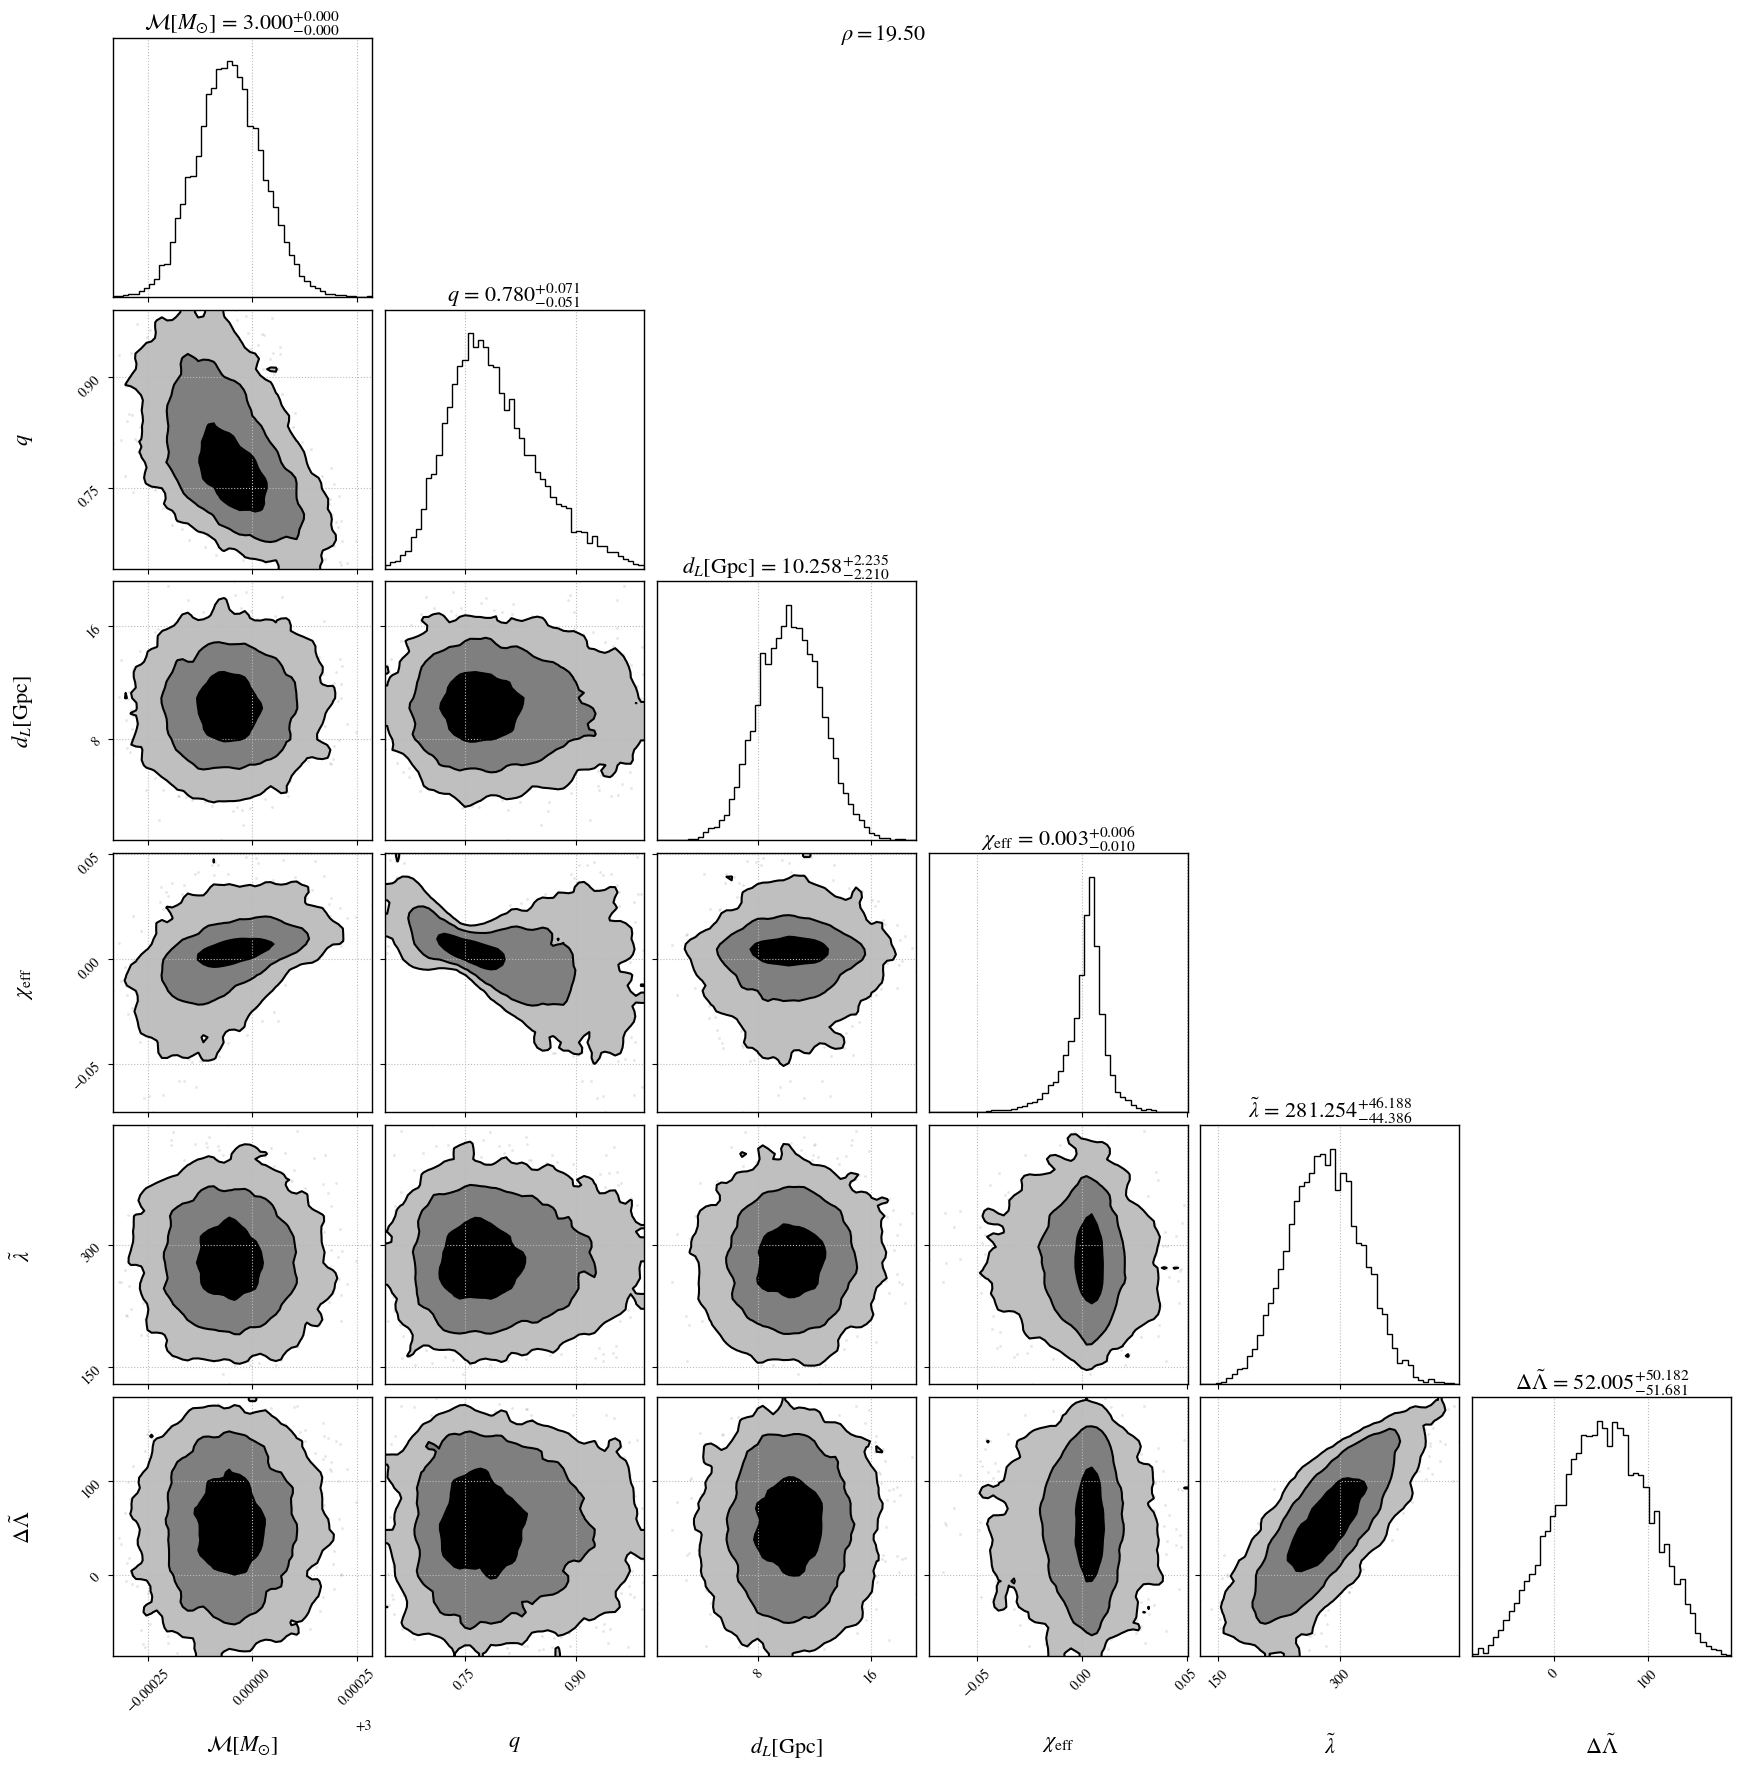

In [2]:
parent_directory = '/ligo/shared-scratch/shiksha.pandey/ce_stm_data/bns/networks/'
file_path = f'{parent_directory}/network_bns_CE40km_1p5MW_Aplus_coat_7.0hz_CE20km_1p5MW_Aplus_coat_7.0hz_ETD_5.0hz.h5'
event_index = 3
number_of_samples = 1e4
fisher_results = FisherResults(file_path=file_path)
posterior_samples = fisher_results.load_event_parameters(event_index, number_of_samples, rng = 250114, npool = 10, tides = True, enforce_physicality = True)
figure = plot_corner(posterior_samples, save=False, parameters = ['chirp_mass', 'mass_ratio', 'luminosity_distance', 'chi_eff', 'lambda_tilde', 'delta_lambda_tilde'])

In [3]:
events = fisher_results.load(parameters = ['luminosity_distance', 'chirp_mass', 'theta_jn'])

In [4]:
from plot_utils import *
_VALID_Y_AXES = ('number_of_events', 'fraction_of_events')

def _label(results_list):
    """Network label from metadata."""
    return [r['metadata']['detectors'] for r in results_list]


def _one_minus_cdf(values, total=None):
    x = numpy.sort(values)
    counts = numpy.arange(len(x), 0, -1)   # N, N-1, ..., 1
    y = counts / total if total is not None else counts
    return x, y


def plot_1cdf(results_list,
              quantity,
              axes = None,
              colors = None,
              linestyles = None,
              labels = None,
              y_axis = 'fraction_of_events',
              save = False,
              legend = False,
              filename = None):
    
    if y_axis not in _VALID_Y_AXES:
        raise ValueError(f"y_axis must be one of {_VALID_Y_AXES}, got '{y_axis}'")

    pylab.rcParams.update(new_rcParams(width='column'))

    if axes is None:
        figure, axes = pylab.subplots()
    else:
        figure = axes.get_figure()

    labels     = labels     or _label(results_list)
    colors     = colors     or [None] * len(results_list)
    linestyles = linestyles or ['-']  * len(results_list)

    for r, label, color, ls in zip(results_list, labels, colors, linestyles):
        try:
            values = numpy.array([ev[quantity] for ev in r['events']])
        except KeyError:
            raise KeyError(
                f"'{quantity}' not found in events. "
                f"Did you request it in load(parameters=[...])?  "
                f"Available keys: {list(r['events'][0].keys())}"
            )

        values = values[numpy.isfinite(values)]

        total = (r['metadata']['total_number_of_events']
                 if y_axis == 'fraction_of_events' else None)

        x, y = _one_minus_cdf(values, total=total)
        axes.plot(x, y, label=label, color=color, linestyle=ls)

    axes.set_xscale('log')
    axes.set_yscale('log')
    axes.set_xlabel(GWlatex_labels.get(quantity, quantity))
    axes.set_ylabel(
        r'$\mathrm{Fraction\ of\ events}$' if y_axis == 'fraction_of_events'
        else r'$\mathrm{No.\ of\ events}$'
    )
    axes.grid(True)
    if legend:
        axes.legend()

    if save:
        filename = filename or f'1cdf_{quantity}.pdf'
        figure.savefig(filename)

    return axes


def add_shared_legend(figure, ax=None, ncol=1, **legend_kwargs):
    """
    Add a single de-duplicated legend to a multi-panel figure.
 
    Two modes:
      - ``ax`` provided : legend is drawn inside that axes panel (the panel's
                          axis lines and ticks are hidden), matching the style
                          of the reference figure where the bottom-right cell
                          is used as the legend panel.
      - ``ax`` is None  : legend floats below the figure via figure.legend().
 
    Parameters
    ----------
    figure : matplotlib.figure.Figure
    ax : matplotlib.axes.Axes, optional
        An empty axes to use as the legend panel (e.g. axes[2, 1]).
        Pass the unused subplot and this function clears it and renders
        the legend there.
    ncol : int, optional
        Number of columns in the legend. Default 1 suits the in-panel mode;
        increase for the external floating mode.
    **legend_kwargs
        Passed through to ax.legend() or figure.legend().
 
    Returns
    -------
    legend object
 
    Examples
    --------
    # In-panel legend (matches reference figure style):
    figure, axes = pylab.subplots(3, 2)
    plot_1cdf(results, 'snr',        axes=axes[0, 0], legend=False)
    plot_1cdf(results, 'sky_area_90',axes=axes[0, 1], legend=False)
    # ... more panels ...
    add_shared_legend(figure, ax=axes[2, 1])   # bottom-right cell = legend
 
    # External floating legend:
    add_shared_legend(figure, ncol=3)
    """
    # Collect handles/labels from all data axes, skip the legend panel itself
    seen = {}
    for a in figure.axes:
        if a is ax:
            continue
        for handle, label in zip(*a.get_legend_handles_labels()):
            if label not in seen:
                seen[label] = handle
 
    handles = list(seen.values())
    labels  = list(seen.keys())
 
    legend_kwargs.setdefault('fancybox', False)
    legend_kwargs.setdefault('shadow',   False)
    legend_kwargs.setdefault('frameon',  True)
 
    if ax is not None:
        ax.set_axis_off()       # hide ticks, spines, background
        return ax.legend(
            handles, labels,
            loc='center',
            ncol=ncol,
            **legend_kwargs,
        )
    else:
        legend_kwargs.setdefault('loc',            'upper center')
        legend_kwargs.setdefault('bbox_to_anchor', (0.5, -0.05))
        return figure.legend(
            handles, labels,
            ncol=ncol,
            **legend_kwargs,
        )    

2026-06-25 16:52:59,913 - INFO - Loaded Fisher file:
/ligo/shared-scratch/shiksha.pandey/ce_stm_data/bns/networks//network_bns_CE40km_1p5MW_Aplus_coat_7.0hz_ETD_5.0hz.h5
 which has detectors : CE40 (1.5MW A+), ET
 If I put an SNR threshold of: 10.0
 then I detected : 39568 / 109267 events
2026-06-25 16:53:00,210 - INFO - Loaded Fisher file:
/ligo/shared-scratch/shiksha.pandey/ce_stm_data/bns/networks//network_bns_CE40km_1p0MW_aLIGO_coat_7.0hz_CE20km_1p0MW_aLIGO_coat_7.0hz_LIA+_10.0hz.h5
 which has detectors : CE40 (1.0MW aLIGO) CE20 (1.0MW), LIA+
 If I put an SNR threshold of: 10.0
 then I detected : 21338 / 109267 events
2026-06-25 16:53:00,298 - INFO - Loaded Fisher file:
/ligo/shared-scratch/shiksha.pandey/ce_stm_data/bns/networks//network_bns_CE40km_1p5MW_Aplus_coat_7.0hz_ETD_5.0hz_LIA+_10.0hz.h5
 which has detectors : CE40 (1.5MW A+), ET, LIA+
 If I put an SNR threshold of: 10.0
 then I detected : 39641 / 109267 events
2026-06-25 16:53:00,435 - INFO - Loaded Fisher file:
/ligo/sha

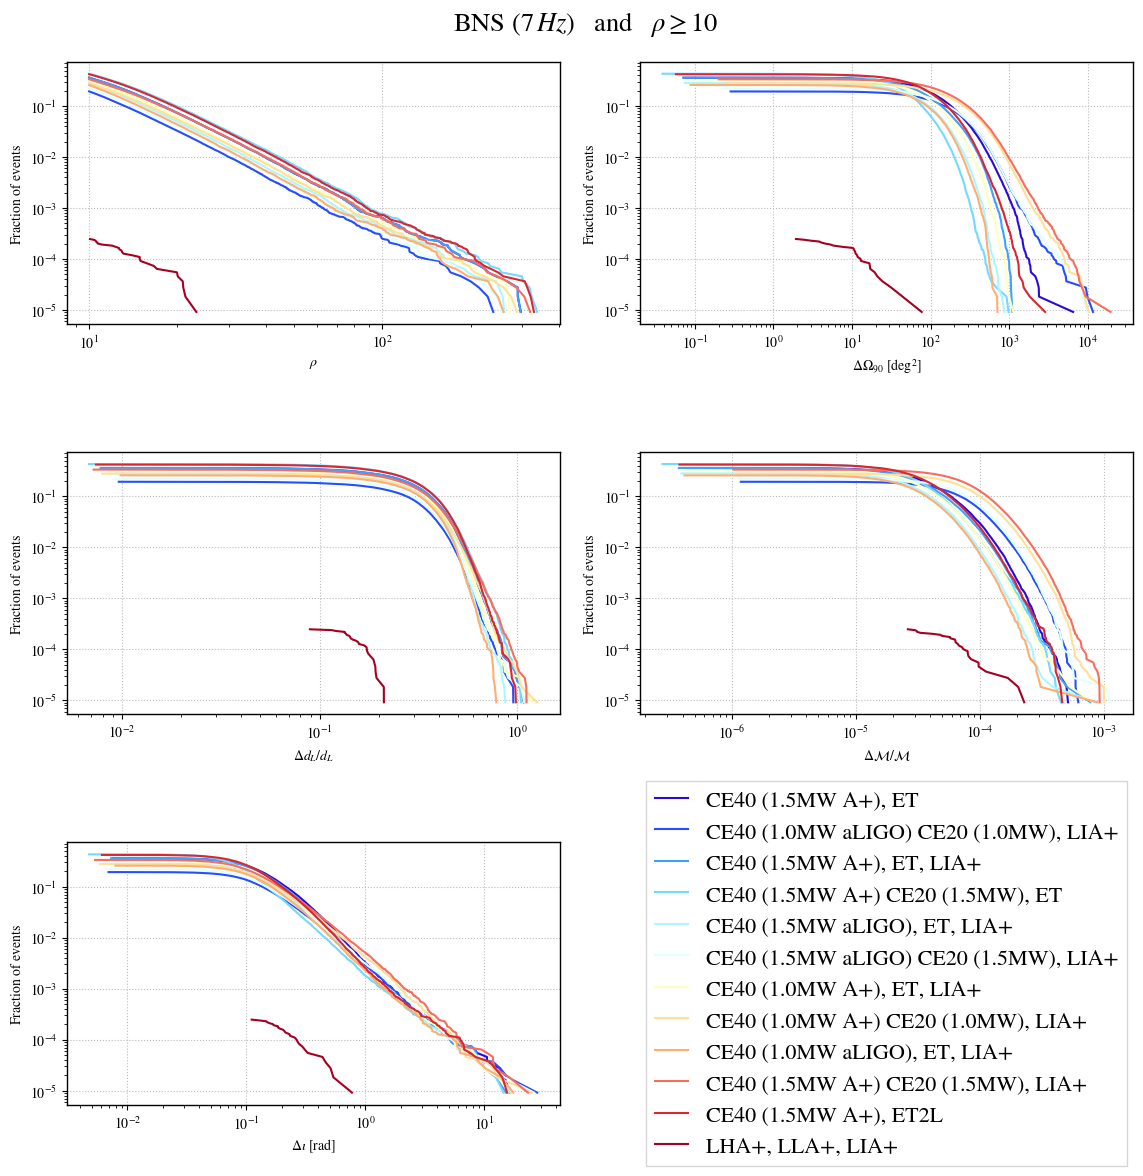

In [5]:
import palettable
results = []
# Load what you need across multiple networks
for file_name in os.listdir(parent_directory):
    if file_name.endswith('.h5') and '7.0hz' in file_name:
        file_path = f'{parent_directory}/{file_name}'
        results.append(
            FisherResults(file_path=file_path).load(parameters=['luminosity_distance', 'chirp_mass', 'theta_jn',
                                        'delta_luminosity_distance_fractional',
                                        'delta_chirp_mass_fractional',
                                        'delta_theta_jn'])
        )
file_path = f'{parent_directory}/network_bns_LHA+_10.0hz_LLA+_10.0hz_LIA+_10.0hz.h5'
results.append(
    FisherResults(file_path=file_path).load(parameters=['luminosity_distance', 'chirp_mass', 'theta_jn',
                                        'delta_luminosity_distance_fractional',
                                        'delta_chirp_mass_fractional',
                                        'delta_theta_jn']))
snr_threshold = results[0]['metadata']['snr_threshold']
pylab.rcParams['axes.prop_cycle'] = pylab.cycler(color=palettable.lightbartlein.diverging.BlueDarkRed12_12.mpl_colors)

# One call per panel
figure, axes = pylab.subplots(3, 2, figsize=(12, 12))
ax1 = plot_1cdf(results, 'snr', axes=axes[0, 0])
ax2 = plot_1cdf(results, 'sky_area_90', axes=axes[0, 1])
ax3 = plot_1cdf(results, 'delta_luminosity_distance_fractional', axes=axes[1, 0])
ax4 = plot_1cdf(results, 'delta_chirp_mass_fractional', axes=axes[1, 1])
ax5 = plot_1cdf(results, 'delta_theta_jn', axes=axes[2, 0])
add_shared_legend(figure, ax=axes[2, 1])  # bottom-right cell becomes the legend panel
figure.suptitle(fr'BNS $(7\,Hz) \quad \text{{and}} \quad \rho \geq {snr_threshold:.0f}$')
figure.tight_layout()


2026-06-25 16:53:04,237 - INFO - Loaded Fisher file:
/ligo/shared-scratch/shiksha.pandey/ce_stm_data/bns/networks//network_bns_CE40km_1p5MW_Aplus_coat_10.0hz_CE20km_1p5MW_Aplus_coat_10.0hz_ETD_5.0hz.h5
 which has detectors : CE40 (1.5MW A+) CE20 (1.5MW), ET
 If I put an SNR threshold of: 10.0
 then I detected : 46301 / 109267 events
2026-06-25 16:53:04,392 - WARNING - Could not compute 'delta_theta_jn' for event 108818: math domain error
2026-06-25 16:53:04,397 - INFO - Loaded Fisher file:
/ligo/shared-scratch/shiksha.pandey/ce_stm_data/bns/networks//network_bns_CE40km_1p0MW_aLIGO_coat_7.0hz_CE20km_1p0MW_aLIGO_coat_7.0hz_LIA+_10.0hz.h5
 which has detectors : CE40 (1.0MW aLIGO) CE20 (1.0MW), LIA+
 If I put an SNR threshold of: 10.0
 then I detected : 21338 / 109267 events
2026-06-25 16:53:04,484 - INFO - Loaded Fisher file:
/ligo/shared-scratch/shiksha.pandey/ce_stm_data/bns/networks//network_bns_CE40km_1p5MW_aLIGO_coat_15.0hz_ETD_5.0hz_LIA+_10.0hz.h5
 which has detectors : CE40 (1.5MW 

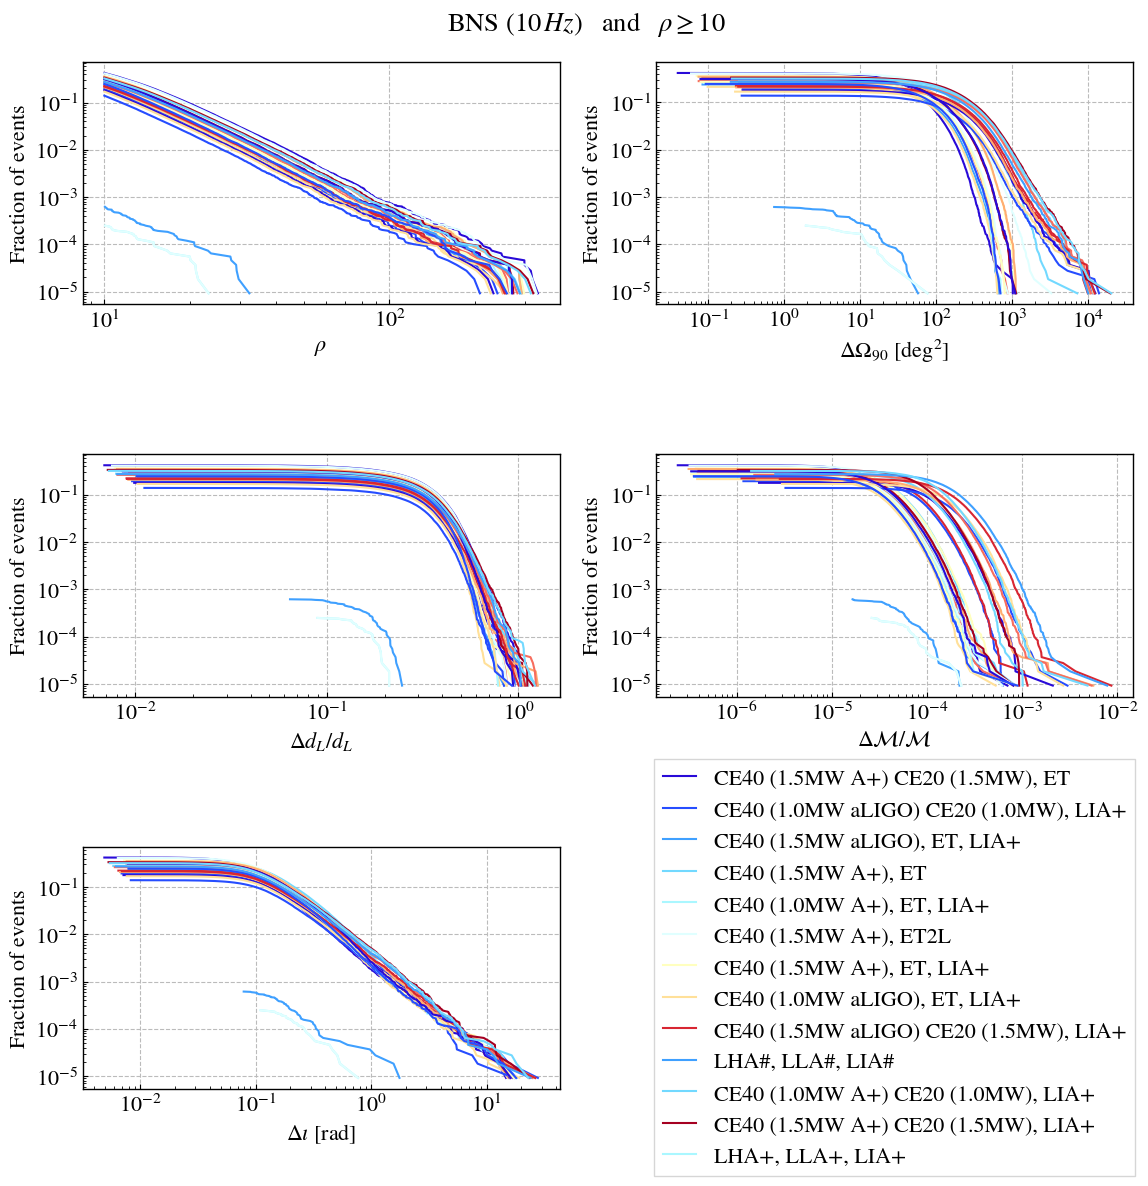

In [6]:
import palettable
results = []
# Load what you need across multiple networks
for file_name in os.listdir(parent_directory):
    if file_name.endswith('.h5') and '10.0hz' in file_name:
        file_path = f'{parent_directory}/{file_name}'
        results.append(
            FisherResults(file_path=file_path).load(parameters=['luminosity_distance', 'chirp_mass', 'theta_jn',
                                        'delta_luminosity_distance_fractional',
                                        'delta_chirp_mass_fractional',
                                        'delta_theta_jn'])
        )
file_path = f'{parent_directory}/network_bns_LHA+_10.0hz_LLA+_10.0hz_LIA+_10.0hz.h5'
results.append(
    FisherResults(file_path=file_path).load(parameters=['luminosity_distance', 'chirp_mass', 'theta_jn',
                                        'delta_luminosity_distance_fractional',
                                        'delta_chirp_mass_fractional',
                                        'delta_theta_jn']))
snr_threshold = results[0]['metadata']['snr_threshold']
pylab.rcParams['axes.prop_cycle'] = pylab.cycler(color=palettable.lightbartlein.diverging.BlueDarkRed12_12.mpl_colors)

# One call per panel
figure, axes = pylab.subplots(3, 2, figsize=(12, 12))
ax1 = plot_1cdf(results, 'snr', axes=axes[0, 0])
ax2 = plot_1cdf(results, 'sky_area_90', axes=axes[0, 1])
ax3 = plot_1cdf(results, 'delta_luminosity_distance_fractional', axes=axes[1, 0])
ax4 = plot_1cdf(results, 'delta_chirp_mass_fractional', axes=axes[1, 1])
ax5 = plot_1cdf(results, 'delta_theta_jn', axes=axes[2, 0])
add_shared_legend(figure, ax=axes[2, 1])  # bottom-right cell becomes the legend panel
figure.suptitle(fr'BNS $(10\,Hz) \quad \text{{and}} \quad \rho \geq {snr_threshold:.0f}$')
figure.tight_layout()


2026-06-25 16:53:11,297 - INFO - Loaded Fisher file:
/ligo/shared-scratch/shiksha.pandey/ce_stm_data/bns/networks//network_bns_CE40km_1p5MW_aLIGO_coat_15.0hz_ETD_5.0hz_LIA+_10.0hz.h5
 which has detectors : CE40 (1.5MW aLIGO), ET, LIA+
 If I put an SNR threshold of: 10.0
 then I detected : 26333 / 109267 events
2026-06-25 16:53:11,394 - INFO - Loaded Fisher file:
/ligo/shared-scratch/shiksha.pandey/ce_stm_data/bns/networks//network_bns_CE40km_1p0MW_aLIGO_coat_15.0hz_ETD_5.0hz_LIA+_10.0hz.h5
 which has detectors : CE40 (1.0MW aLIGO), ET, LIA+
 If I put an SNR threshold of: 10.0
 then I detected : 23531 / 109267 events
2026-06-25 16:53:11,486 - INFO - Loaded Fisher file:
/ligo/shared-scratch/shiksha.pandey/ce_stm_data/bns/networks//network_bns_CE40km_1p5MW_Aplus_coat_15.0hz_ETD_5.0hz.h5
 which has detectors : CE40 (1.5MW A+), ET
 If I put an SNR threshold of: 10.0
 then I detected : 34244 / 109267 events
2026-06-25 16:53:11,607 - INFO - Loaded Fisher file:
/ligo/shared-scratch/shiksha.pan

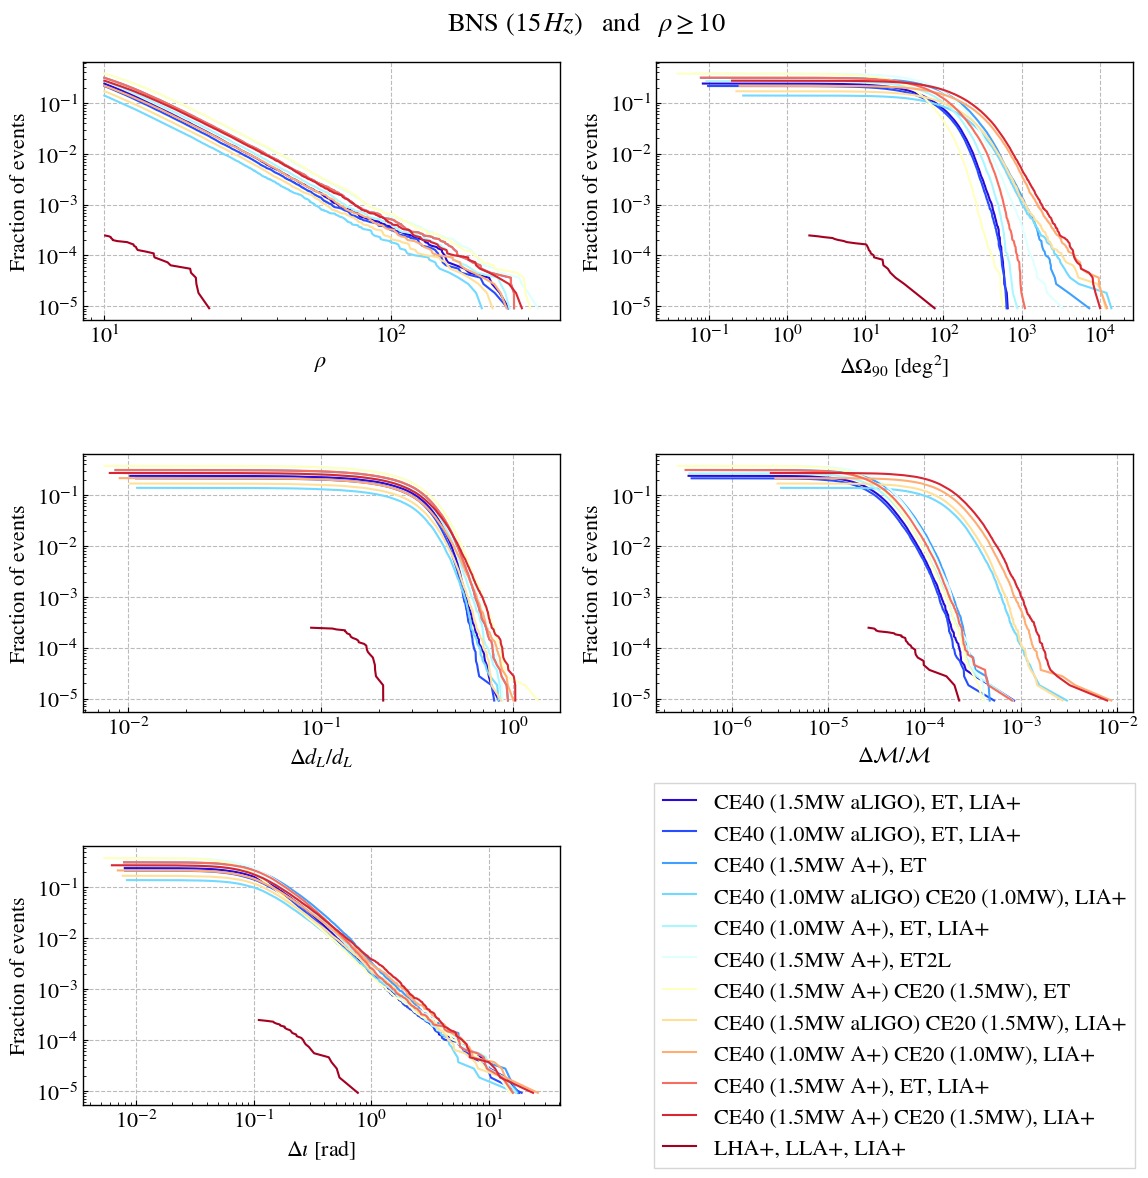

In [7]:
import palettable
results = []
# Load what you need across multiple networks
for file_name in os.listdir(parent_directory):
    if file_name.endswith('.h5') and '15.0hz' in file_name:
        file_path = f'{parent_directory}/{file_name}'
        results.append(
            FisherResults(file_path=file_path).load(parameters=['luminosity_distance', 'chirp_mass', 'theta_jn',
                                        'delta_luminosity_distance_fractional',
                                        'delta_chirp_mass_fractional',
                                        'delta_theta_jn'])
        )
file_path = f'{parent_directory}/network_bns_LHA+_10.0hz_LLA+_10.0hz_LIA+_10.0hz.h5'
results.append(
    FisherResults(file_path=file_path).load(parameters=['luminosity_distance', 'chirp_mass', 'theta_jn',
                                        'delta_luminosity_distance_fractional',
                                        'delta_chirp_mass_fractional',
                                        'delta_theta_jn']))
snr_threshold = results[0]['metadata']['snr_threshold']
pylab.rcParams['axes.prop_cycle'] = pylab.cycler(color=palettable.lightbartlein.diverging.BlueDarkRed12_12.mpl_colors)

# One call per panel
figure, axes = pylab.subplots(3, 2, figsize=(12, 12))
ax1 = plot_1cdf(results, 'snr', axes=axes[0, 0])
ax2 = plot_1cdf(results, 'sky_area_90', axes=axes[0, 1])
ax3 = plot_1cdf(results, 'delta_luminosity_distance_fractional', axes=axes[1, 0])
ax4 = plot_1cdf(results, 'delta_chirp_mass_fractional', axes=axes[1, 1])
ax5 = plot_1cdf(results, 'delta_theta_jn', axes=axes[2, 0])
add_shared_legend(figure, ax=axes[2, 1])  # bottom-right cell becomes the legend panel
figure.suptitle(fr'BNS $(15\,Hz) \quad \text{{and}} \quad \rho \geq {snr_threshold:.0f}$')
figure.tight_layout()


In [8]:
import sys, os
sys.path.insert(0, os.path.abspath('codes'))
from plot_utils import *
import h5py,json, pandas, logging
from pesummary.core.plots.bounded_1d_kde import bounded_1d_kde

def load_file(file_path):
    '''
    Parameters
    -----------
    file_path: str, path to the HDF5 file containing the data

    Returns
    -------
    snrs: array-like, SNR values of the events
    redshift: array-like, redshift values of the events
    snr_threshold: float, the SNR threshold used for detection
    total_number_of_events: int, total number of events in the dataset
    detected_events: int, number of events that were detected (SNR above threshold)
    '''
    f = h5py.File(file_path, 'r')
    snr_threshold = f.attrs['snr_threshold']
    total_number_of_events = f.attrs['total_events']
    detectors = f.attrs['detectors']
    detected_events = f.attrs['detected_events']

    detectors = parse_combo(detectors)

    logging.info(f'Assuming SNR threshold of {snr_threshold}, '
                 f'total number of events {total_number_of_events}, \n'
                 f'detectors {detectors}, and detected events {detected_events}; \n'
                 f'A detection efficiency of {detected_events/total_number_of_events * 100:.2f}% is obtained.')    

    snrs = f['snr'][:]
    sky_area_90 = f['sky_area_90'][:]
    mass_1, mass_2 = f['event_parameters']['m1_src'][:], f['event_parameters']['m2_src'][:]
    spin_1z, spin_2z = f['event_parameters']['chi1z'][:], f['event_parameters']['chi2z'][:]
    luminosity_distance, redshift = f['event_parameters']['dL'][:], f['event_parameters']['z'][:]
    ra, dec = f['event_parameters']['ra'][:], f['event_parameters']['dec'][:]
    f.close()
    return snrs, redshift, snr_threshold, total_number_of_events, detected_events, detectors

def plot_detection_efficiency(snrs, redshift,
                              snr_threshold, total_number_of_events, detected_events,
                              z_split=None,
                              n_bins=40,
                              isotonic=True,
                              axes=None, label=None, color=None,
                              show_raw=False, trim_zero_tail=False):
    '''
    snrs: array-like, SNR values of the events
    redshift: array-like, redshift values of the events
    snr_threshold: float or array-like, the SNR threshold used for detection
    total_number_of_events: int, total number of events in the dataset
    detected_events: int, number of events that were detected (SNR above threshold)
    z_split: float, optional, currently unused (reserved for splitting the
        binning into a fine low-z range and a coarse high-z range)
    n_bins: int, number of log-spaced redshift bins
    isotonic: bool, if True (default) fit a monotonically non-increasing
        curve through the binned efficiencies via isotonic regression
        (pool-adjacent-violators), weighted by per-bin event counts. This
        enforces what the definition of detection efficiency requires --
        see Eq. 2 in the detection-rate writeup: epsilon(z, rho*) is the
        fraction of sources within z that clear the SNR threshold, which
        can only decrease (or stay flat) as z increases. A raw binned
        curve going 1.0 -> 0.5 -> 1.0 -> 0.0 etc. is never physical; it's
        Poisson noise in low-N bins being mistaken for signal. Isotonic
        regression pools adjacent bins exactly where (and only where) the
        data can't statistically distinguish a decrease, which subsumes
        manual bin-merging without throwing away resolution where the
        statistics are good (e.g. your well-sampled CE-class networks
        will barely be touched; your low-N networks will be smoothed
        considerably more).
    axes: matplotlib axes object, optional, the axes on which to plot the detection efficiency curve
    label: str, optional, label for the detection efficiency curve
    color: str, optional, color for the detection efficiency curve
    show_raw: bool, if True, also plot the raw (pre-isotonic) binned curve
        as a faint dashed line for comparison/diagnostics
    trim_zero_tail: bool, if True (default), drop trailing bins once the
        (isotonic) efficiency first reaches exactly 0 and stays there --
        the long flat-zero tail at high z carries no information once
        you're past the point where the curve has converged, so there's
        no reason to keep plotting/storing it. Only trims the tail, not a
        leading run of 1.0s, since a long run of perfect detection at low
        z is real signal worth keeping (and trimming it would be
        misleading the other direction).
    Return:
    -----
    axes: matplotlib axes object, the axes on which the detection efficiency curve is plotted
    detection_efficiencies: array-like, the calculated (isotonic, if
        requested) detection efficiency for each redshift bin
    bin_centers: array-like, the redshift bin centers
    '''
    # Create a DataFrame for easier plotting
    if axes is None:
        pylab.figure()
        axes = pylab.gca()
 
    data = pandas.DataFrame({'snr': snrs, 'redshift': redshift})
    bins = numpy.logspace(numpy.log10(data['redshift'].min()), numpy.log10(data['redshift'].max()), n_bins)
    bin_centers = (bins[:-1] + bins[1:]) / 2
 
    counts, detected_counts = [], []
    for i in range(len(bins) - 1):
        bin_mask = (data['redshift'] >= bins[i]) & (data['redshift'] < bins[i + 1])
        bin_data = data[bin_mask]
        counts.append(len(bin_data))
        detected_counts.append((bin_data['snr'] >= snr_threshold).sum())
 
    counts = numpy.asarray(counts)
    detected_counts = numpy.asarray(detected_counts)
 
    has_data = counts > 0
    raw_effs = numpy.full(len(counts), numpy.nan)
    raw_effs[has_data] = detected_counts[has_data] / counts[has_data]
 
    if show_raw:
        axes.plot(bin_centers, raw_effs, marker='o', markersize=3, linestyle='--',
                  alpha=0.35, color=color, label=None)
 
    if not isotonic:
        if trim_zero_tail:
            bin_centers, raw_effs = _trim_zero_tail(bin_centers, raw_effs)
        axes.plot(bin_centers, raw_effs, marker='o', linestyle='-', label=label, color=color)
        return axes, raw_effs, bin_centers
 
    # Isotonic regression (pool-adjacent-violators), weighted by per-bin
    # counts, enforcing efficiency non-increasing in redshift. Empty bins
    # are dropped before fitting (no weight, no information) and the fit
    # is then evaluated back at all bin centers, including any empty ones,
    # by linear interpolation between the nearest fitted points.
    from sklearn.isotonic import IsotonicRegression
 
    fit_x = bin_centers[has_data]
    fit_y = raw_effs[has_data]
    fit_w = counts[has_data]
 
    iso = IsotonicRegression(y_min=0.0, y_max=1.0, increasing=False, out_of_bounds='clip')
    iso.fit(fit_x, fit_y, sample_weight=fit_w)
    smoothed_effs = iso.predict(bin_centers)
 
    if numpy.any(~has_data):
        logging.info(f"'{label}': {numpy.sum(~has_data)} of {n_bins-1} bins had zero "
                      f"events and were excluded from the isotonic fit (values "
                      f"shown there are interpolated/clipped, not measured).")
 
    if trim_zero_tail:
        plot_centers, smoothed_effs_trimmed = _trim_zero_tail(bin_centers, smoothed_effs)
        axes.plot(plot_centers, smoothed_effs_trimmed, marker='o', linestyle='-', label=label, color=color)
    else:
        axes.plot(bin_centers, smoothed_effs, marker='o', linestyle='-', label=label, color=color)
    return axes, smoothed_effs, bin_centers
 
 
def _trim_zero_tail(x, y):
    '''
    Drop trailing points once y first reaches (and stays at) exactly 0,
    keeping one zero point so the curve still visibly touches the axis.
    '''
    y = numpy.asarray(y)
    nonzero = numpy.where((y > 0) | numpy.isnan(y))[0]
    if len(nonzero) == 0 or nonzero[-1] >= len(y) - 1:
        return x, y  # nothing to trim
    cutoff = nonzero[-1] + 2  # keep one zero point past the last nonzero one
    cutoff = min(cutoff, len(y))
    return x[:cutoff], y[:cutoff]

2026-06-25 16:53:15,334 - INFO - font.family must be one of (serif, sans-serif, cursive, monospace) when text.usetex is True. serif will be used by default.


2026-06-25 16:53:15,350 - INFO - Assuming SNR threshold of 10.0, total number of events 109267, 
detectors CE40 (1.5MW A+), ET, and detected events 39568; 
A detection efficiency of 36.21% is obtained.
2026-06-25 16:53:15,374 - INFO - Assuming SNR threshold of 10.0, total number of events 109267, 
detectors CE40 (1.0MW aLIGO) CE20 (1.0MW), LIA+, and detected events 21338; 
A detection efficiency of 19.53% is obtained.
2026-06-25 16:53:15,397 - INFO - Assuming SNR threshold of 10.0, total number of events 109267, 
detectors CE40 (1.5MW A+), ET, LIA+, and detected events 39641; 
A detection efficiency of 36.28% is obtained.
2026-06-25 16:53:15,420 - INFO - Assuming SNR threshold of 10.0, total number of events 109267, 
detectors CE40 (1.5MW A+) CE20 (1.5MW), ET, and detected events 47463; 
A detection efficiency of 43.44% is obtained.
2026-06-25 16:53:15,442 - INFO - Assuming SNR threshold of 10.0, total number of events 109267, 
detectors CE40 (1.5MW aLIGO), ET, LIA+, and detected event

Text(0.5, 1.0, 'Detection Efficiency vs Redshift for BNS $(7\\,Hz) \\quad \\text{and} \\quad \\rho \\geq 10$')

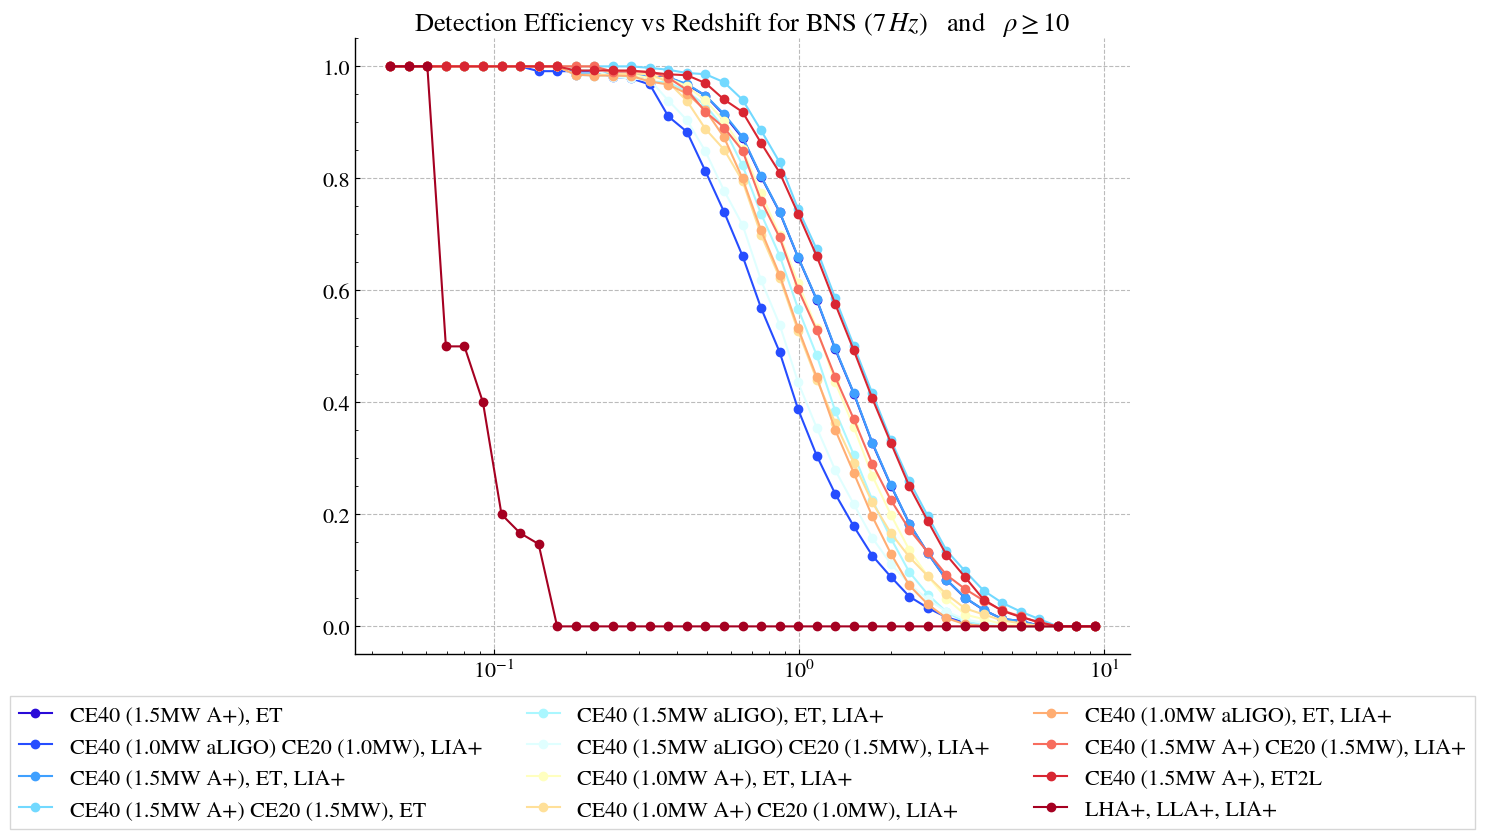

In [9]:
import palettable
parent_directory = '/ligo/shared-scratch/shiksha.pandey/ce_stm_data/bns/networks/'

# Gather files first so we know the plotting order ahead of time
file_names = [f for f in os.listdir(parent_directory)
              if f.endswith('.h5') and '7.0hz' in f]
extra_file = 'network_bns_LHA+_10.0hz_LLA+_10.0hz_LIA+_10.0hz.h5'
all_file_paths = [f'{parent_directory}/{f}' for f in file_names] + [f'{parent_directory}/{extra_file}']

# Pre-load just enough to get `detectors` for each file, in plot order
all_detectors = []
loaded = []  # cache full load_file() output so we don't read each file twice
for file_path in all_file_paths:
    result = load_file(file_path)
    loaded.append(result)
    detectors = result[-1]  # last item returned by load_file
    all_detectors.append(detectors)

lengths = [len(d) for d in all_detectors]  # adjust if detectors isn't directly len()-able
max_detectors_seen = 12

pylab.rcParams.update(new_rcParams())
pylab.rcParams['axes.prop_cycle'] = pylab.cycler(color=palettable.lightbartlein.diverging.BlueDarkRed12_12.mpl_colors)

pylab.figure(figsize=(10, 8))
axes = pylab.gca()

for result in loaded:
    (snrs, redshift, snr_threshold,
     total_number_of_events, detected_events, detectors) = result

    axes, _, _ = plot_detection_efficiency(
        snrs, redshift, snr_threshold=10,
        total_number_of_events=total_number_of_events,
        detected_events=detected_events,
        axes=axes, label=detectors  # no color kwarg — picked up from the cycle
    )

axes.set_xscale('log')
sns.despine()
axes.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
            fancybox=False, shadow=False, ncol=3)
pylab.title(fr'Detection Efficiency vs Redshift for BNS $(7\,Hz) \quad \text{{and}} \quad \rho \geq {snr_threshold:.0f}$')

2026-06-25 16:53:16,448 - INFO - Assuming SNR threshold of 10.0, total number of events 109267, 
detectors CE40 (1.5MW aLIGO), ET, LIA+, and detected events 26333; 
A detection efficiency of 24.10% is obtained.
2026-06-25 16:53:16,472 - INFO - Assuming SNR threshold of 10.0, total number of events 109267, 
detectors CE40 (1.0MW aLIGO), ET, LIA+, and detected events 23531; 
A detection efficiency of 21.54% is obtained.
2026-06-25 16:53:16,495 - INFO - Assuming SNR threshold of 10.0, total number of events 109267, 
detectors CE40 (1.5MW A+), ET, and detected events 34244; 
A detection efficiency of 31.34% is obtained.
2026-06-25 16:53:16,517 - INFO - Assuming SNR threshold of 10.0, total number of events 109267, 
detectors CE40 (1.0MW aLIGO) CE20 (1.0MW), LIA+, and detected events 15340; 
A detection efficiency of 14.04% is obtained.
2026-06-25 16:53:16,540 - INFO - Assuming SNR threshold of 10.0, total number of events 109267, 
detectors CE40 (1.0MW A+), ET, LIA+, and detected events 29

Text(0.5, 1.0, 'Detection Efficiency vs Redshift for BNS $(15\\,Hz) \\quad \\text{and} \\quad \\rho \\geq 10$')

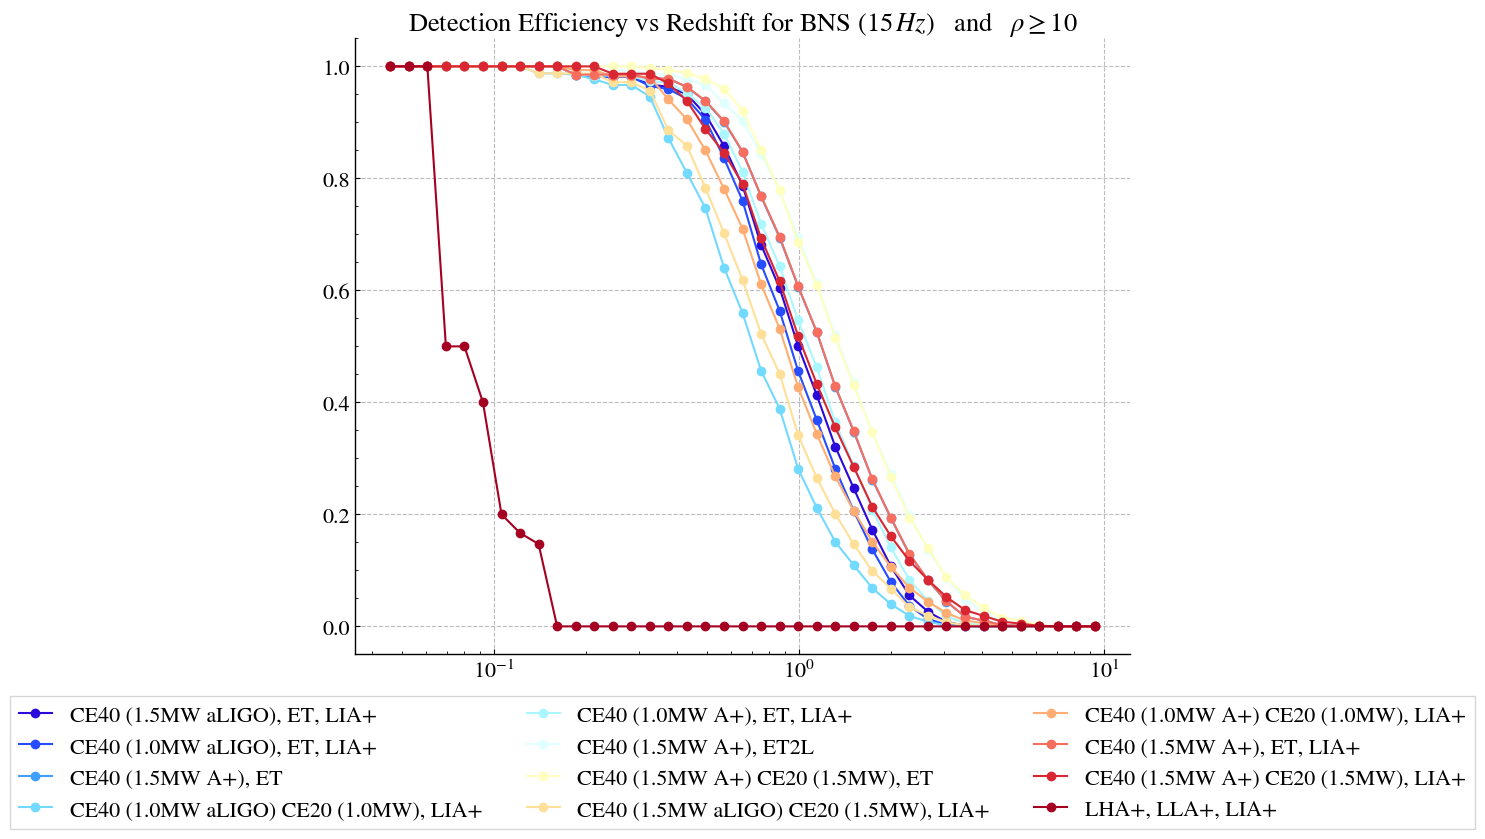

In [10]:
import palettable
parent_directory = '/ligo/shared-scratch/shiksha.pandey/ce_stm_data/bns/networks/'

# Gather files first so we know the plotting order ahead of time
file_names = [f for f in os.listdir(parent_directory)
              if f.endswith('.h5') and '15.0hz' in f]
extra_file = 'network_bns_LHA+_10.0hz_LLA+_10.0hz_LIA+_10.0hz.h5'
all_file_paths = [f'{parent_directory}/{f}' for f in file_names] + [f'{parent_directory}/{extra_file}']

# Pre-load just enough to get `detectors` for each file, in plot order
all_detectors = []
loaded = []  # cache full load_file() output so we don't read each file twice
for file_path in all_file_paths:
    result = load_file(file_path)
    loaded.append(result)
    detectors = result[-1]  # last item returned by load_file
    all_detectors.append(detectors)

lengths = [len(d) for d in all_detectors]  # adjust if detectors isn't directly len()-able
max_detectors_seen = 12

pylab.rcParams.update(new_rcParams())
pylab.rcParams['axes.prop_cycle'] = pylab.cycler(color=palettable.lightbartlein.diverging.BlueDarkRed12_12.mpl_colors)

pylab.figure(figsize=(10, 8))
axes = pylab.gca()

for result in loaded:
    (snrs, redshift, snr_threshold,
     total_number_of_events, detected_events, detectors) = result

    axes, _, _ = plot_detection_efficiency(
        snrs, redshift, snr_threshold=10,
        total_number_of_events=total_number_of_events,
        detected_events=detected_events,
        axes=axes, label=detectors  # no color kwarg — picked up from the cycle
    )

axes.set_xscale('log')
sns.despine()
axes.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
            fancybox=False, shadow=False, ncol=3)
pylab.title(fr'Detection Efficiency vs Redshift for BNS $(15\,Hz) \quad \text{{and}} \quad \rho \geq {snr_threshold:.0f}$')